# Lab 3: AC Signals, Chained Loads, Using a Follower

<span style="background-color:yellow"> Cole Stevens</span>

**Laboratory Outcomes**

* Characterize AC signals using a digital multimeter (DMM) and an oscilloscope
* Measure the gain for chained loads
* Build a follower circuit to isolate loads

## Characterize an AC Signal

### Unknown Signal Measurement: Two instruments 

You will be provided a BNC cable that carries an "unknown" AC signal, and you will use two different instruments to measure and characterize the signal.  

A. **Multimeter** 

1. Use your benchtop **d**igital **m**ulti**m**eter (DMM) as an AC voltmeter to measure the voltage,  frequency and period of this signal. You will need to figure out how to do this by determining how to connect the BNC cable to the DMM, and what buttons to press on the DMM to make the different measurements. Describe how each measurement was done and report the result of each one.  

<span style="background-color:yellow">
Voltage (AC): 0.8655 V
    Taken by plugging the BNC cable with a gnd/input splitter into the right red/black ports of the DMM and hitting the "AC V" button.</br>
Frequency: 75 Hz
    Taken by plugging the BNC cable with a gnd/input splitter into the right red/black ports of the DMM and hitting the "Freq" button.</br>
Period: 13.333 msec
    Taken by plugging the BNC cable with a gnd/input splitter into the right red/black ports of the DMM and hitting the "Shift" button then the "Freq" button.

</span>

2. Based on your measured values sketch your best guess of what your unknown signal looks like, voltage (vertical) vs. time (horizontal). Label all the important characteristics of the AC signal on your drawing.  

<span style="background-color:yellow">
    
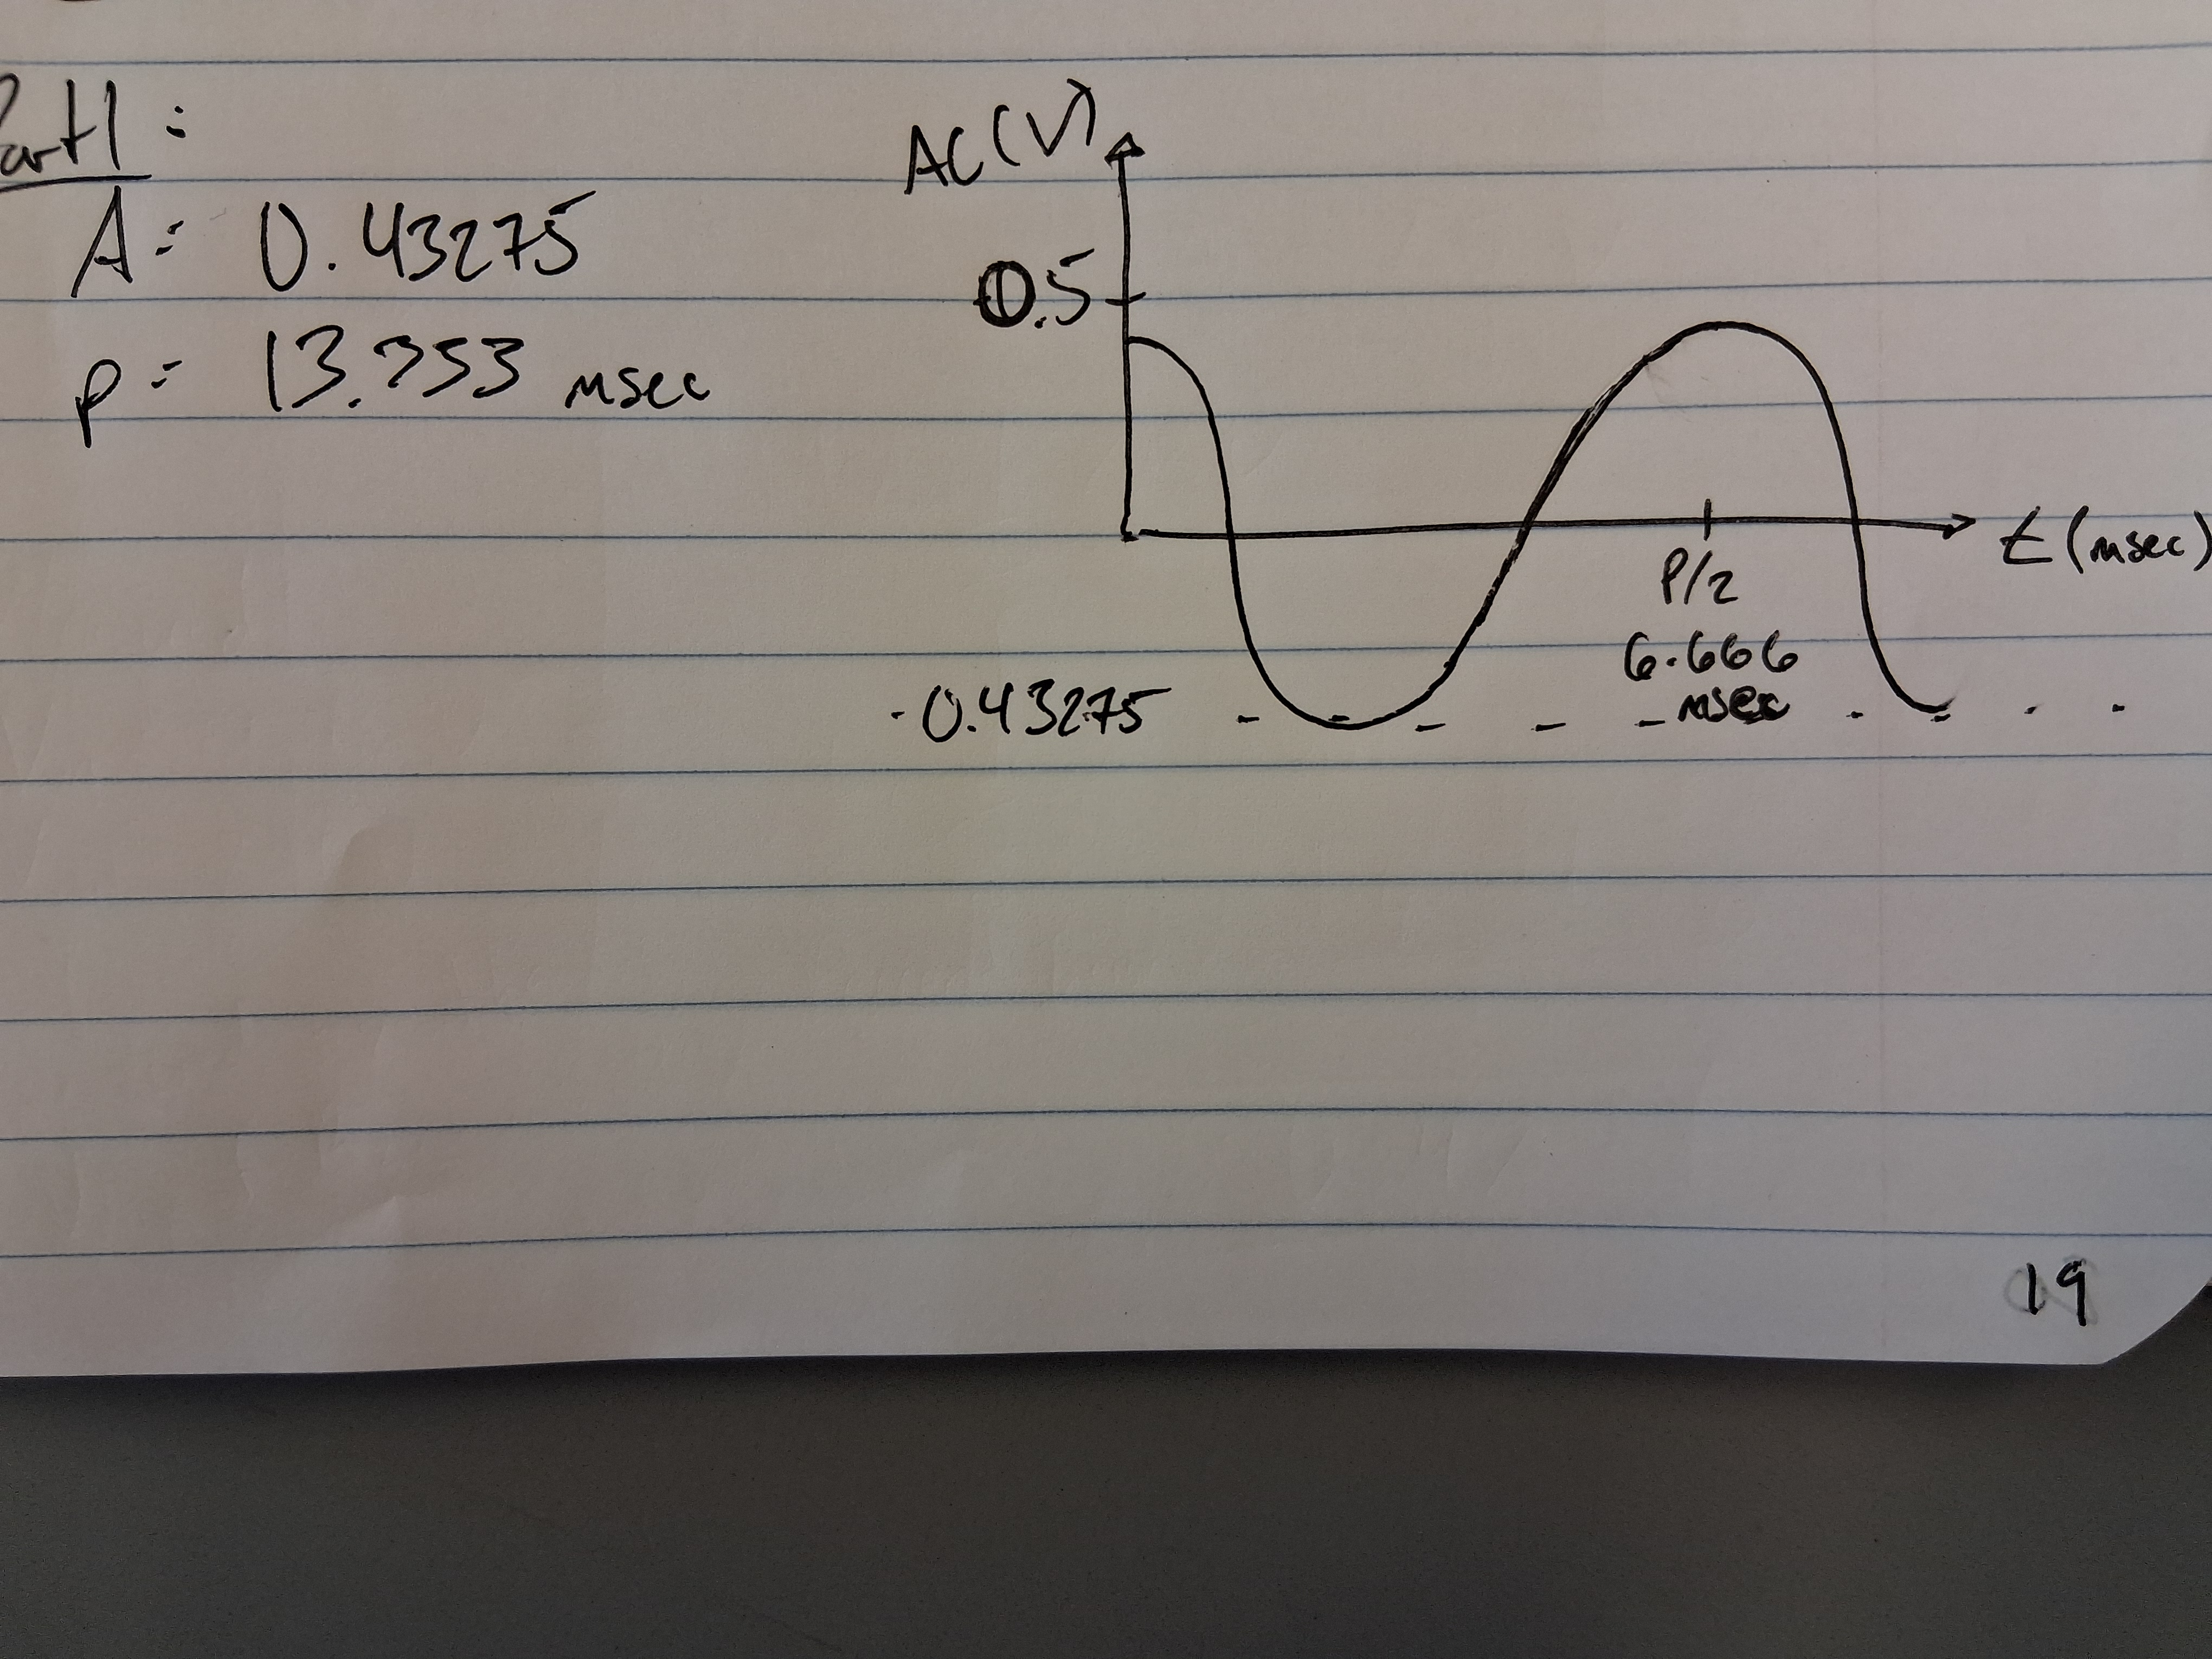</span>

B. **Oscilloscope** 

Now use your oscilloscope to again measure the properties of the unknown signal. The oscilloscope is more complicated than the DMM, so it may take you a bit longer to figure out the proper settings to display your signal on the oscilloscope screen.

3. To begin with, use the vertical (volts/div) and horizontal (time/div) knobs, and triggering buttons/settings to adjust your screen display so that you get a visible stable signal (similar to the At-Home Activity).  Once you have a trace, use the oscilloscope to measure the values of the important quantities that characterize your AC signal. Record your values and the details of the method you used to determine them in your notebook. (There are different ways to make "measurements" on the scope.)

<span style="background-color:yellow">
After adjusting the graph to show a stable signal:</br>
Peak-Peak Voltage (AC): 3 V
    Taken by plugging the BNC cable into the "1" port of the OSC and hitting the "Meas" button in the "Measure section in the center of the button board.</br>
Frequency: 75 Hz
    Taken by plugging the BNC cable into the "1" port of the OSC and hitting the "Meas" button in the "Measure section in the center of the button board.</br>
Period: 13.33 msec
    Taken by plugging the BNC cable into the "1" port of the OSC and hitting the "Meas" button in the "Measure section in the center of the button board. After that, use the buttons below the bottom digital menu to change the type to period, clear a measurement, then add the measurement back to change the measurement from frequency to period.
</span>

## Conference

Discuss your results with your labmates.  Are their signals the same as or different than yours? Did you measure the waveform parameters the same way as your labmates?

## Getting and plotting data from your oscilloscope

Having adjusted the vertical (volts/div) and horizontal (time/div) scales you now have an stable display (trace) of the waveform on your oscilloscope. We want to get the data and plot it. 

The commands in the following cells will 
* determine the address of your oscilloscope,
* get information about the settings (vertical and horizontal scales), and
* display a figure corresponding to the oscilloscope trace which you can save.

Run the cells in order and be sure you understand the commands and the outputs.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pyvisa
import pandas as pd

## RUN THIS CELL

In [3]:
rm = pyvisa.ResourceManager() # resource manager object
rm.list_resources() 

## RUN THIS CELL

('USB0::0x0957::0x179B::MY52166481::INSTR',
 'ASRL2::INSTR',
 'ASRL10::INSTR',
 'GPIB0::10::INSTR',
 'GPIB0::22::INSTR',
 'GPIB0::5::INSTR')

If your oscilloscope is connected it will have an address something like the first line:

`'USB0::0x0957::0x179B::MY52498198::0::INSTR'`

Your scope will likely have a different address. Copy that address into the `rm.open_resource` command below. Be sure to include the quotes around the 'address'.

In [5]:
scope = rm.open_resource('USB0::0x0957::0x179B::MY52166481::INSTR') # scope object, use your scope address
timescale = float(scope.query(":TIM:SCAL?")) # time (horizontal) scale as a real number
print('tscale =',timescale, 'seconds/div')
voltagescale = float(scope.query("CHAN1:SCALE?")) # voltage (vertical) scale as a real number
print('vscale =',voltagescale, 'volts/div')

## RUN THIS CELL

tscale = 0.005 seconds/div
vscale = 0.5 volts/div


**QUESTION**: Look at the outputs from the previous cell. Do the values make sense given the "volts/div" and "time/div" settings on your scope?  How can you tell?

<span style="background-color:yellow">The values make sense given the settings on my scope. I can tell bc applying the "volts/div" setting to the graph I can see that the Pk-Pk Voltage is 3 V (which is waht is measured. Using the same process I see the period is correct as well.</span>

The cell below will get voltage data from your oscilloscope and determine the corresponding time steps. (The code isn't written to output anything; if you want to check that it ran, you can create a new cell and print `volt_numdata` to make sure information has been written to this variable.)

In [6]:
scope.write(":WAVeform:SOURce CHANnel1")      # get data from Channel 1 as "source"
scope.write(":WAVeform:FORMat ASCII")         # data format, ASCII strings
volt_stringdata = scope.query_ascii_values(":WAVeform:DATA?","s") # get data as ASCII strings
volt_numdata = np.array(volt_stringdata[1:],dtype = np.float64)   # convert strings to numbers (float)
start = 0.0                    # start of time axis
stop = timescale*volt_numdata.size  # end of time axis
time_axis = np.arange(start,stop,timescale) # time axis points

## RUN THIS CELL

In [7]:
print(volt_numdata)

[ 0.743719  0.723618  0.743719 ... -0.763819 -0.763819 -0.763819]


After you run the cell below you should have a graph of your oscilloscope screen.  You can save this figure by removing the `#` at the start of the last line or right clicking in the figure and choosing "Copy Output to Clipboard".  If you are happy with your plot, you should also save your oscilloscope data as .csv files (the times and the voltages) in case you need it later.

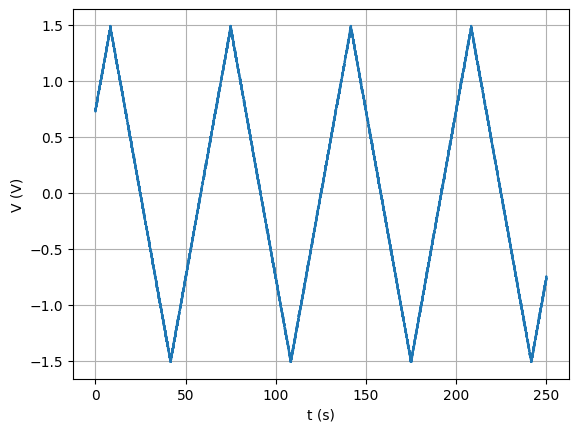

In [10]:
plt.plot(time_axis, volt_numdata,'-')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.grid(True)
plt.savefig('triangle_AC_signal_3012026.png')  # to save, remove "#" at start; give filename

## RUN THIS CELL

## LABORATORY: Two-divider circuit

### Two-divider circuit

**Note:**  For the remainder of the lab, you can go back to using a DC signal from your power supply.  We will return to AC signals in next week's lab.

In At-Home-Assignment 3_2, you built two chained voltage dividers on your breadboard ($V_\text{in}\rightarrow$Divider A$\rightarrow$Divider B$\rightarrow V_\text{out}$).  Take a few measurements to confirm that your breadboard is working in lab as it was at home. 

<span style="background-color:yellow">
$V_\text{in}$ = 5 V $V_\text{out}$ = 1.648</br>
$V_\text{in}$ = 6 V $V_\text{out}$ = 1.978</br>
$V_\text{in}$ = 8 V $V_\text{out}$ = 2.634
</span>

With your dividers connected, measure the voltage at the output of divider A, $V_\text{out, A}$, and the voltage at the output of divider B $V_\text{out, B}$.  Does $V_\text{out, A}=V_\text{in}\bigg(\frac{R_{2}}{R_{1}+R_{2}}\bigg)$?  Does $V_\text{out, B}=V_\text{out, A}\bigg(\frac{R_{4}}{R_{3}+R_{4}}\bigg)$?  Is there a particular part of the chained dividers that changed when you connected dividers A and B, or is everything affected by chaining the dividers?  Explain.

<span style="background-color:yellow">
For $V_\text{out, A}$, it does pretty much equal $V_\text{in}\bigg(\frac{R_{2}}{R_{1}+R_{2}}\bigg)$.
For $V_\text{out, B}$, it does pretty much equal $V_\text{in}\bigg(\frac{R_{2}}{R_{1}+R_{2}}\bigg)$.
There wewre minute changes because of the connecting of the two dividers. Those changes are seen throughout the chain. While chained together, V_A is not perfectly as it was unchained. It is only off by a couple hundredths of a volt, but still a difference. The same goes for V_B.
</span>

### Two-divider circuit: reversed

Now build a similar circuit, but rearrange your resistors so the **dividers are reversed** ($V_\text{in}\rightarrow$Divider B$\rightarrow$Divider A$\rightarrow V_\text{out}$). Again measure the gain of each divider while unconnected, and compare it to the connected gains.  What do you notice?

<span style="background-color:yellow">
Unconnected:
    
|Circuit (Divider)|Gain Calculated|Gain Measured|Percent Error|
|-|-|-|-|
|A|0.5|0.498|0.4%|
|B|0.662|0.664|0.3%|

Connected:
|Circuit (Divider)|Gain Calculated|Gain Measured|Percent Error|
|-|-|-|-|
|A|0.5|0.0283|94.34%|
|B|0.662|0.0375|94.33%|

<br>
I notice that the voltage going into divider A seems to go back into divider B, as both dividers have a $\rightarrow V_\text{out}$ that's only a fraction of a volt. The gain of each divider while connected is in the hundreths, very small compared to the gains I was expecting.</span>

It now appears we have two issues to concern ourselves with. As we might have suspected, the second circuit is *loading* the first circuit and that affects the voltage between the dividers and the final output.  In addition, it looks like the order of the circuits (A then B versus B then A) affects the overall output.  In other words, not only does $G_\text{AB}\neq G_\text{A}G_\text{B}$, but $G_\text{AB}\neq G_\text{BA}$.To avoid these behaviors we'd like some way to isolate the second circuit so it does not load the first circuit.  

## LABORATORY: Using an op-amp follower for isolation

To avoid the problem of one part of a cicuit *loading* the next part of a circuit we can use what is called a buffer between the subcircuits.  A common approach to do this is a *unity gain buffer* constructed out of an **operational amplifier** (op-amp) used as a follower.  (We will use op-amps more later in the course, but for now we will use them to isolate one part of a circuit from another.)

We know from a previous lab  the loading of the first circuit by the second is minimized if the resistance of the second circuit (the load) is large compared to the resistance of the divider.  An op-amp has essentially an "infinite" resistance at the inputs so this makes the loading effect minimal (almost nonexistent).

The schematic below shows an op-amp used as a follower (unity gain buffer).
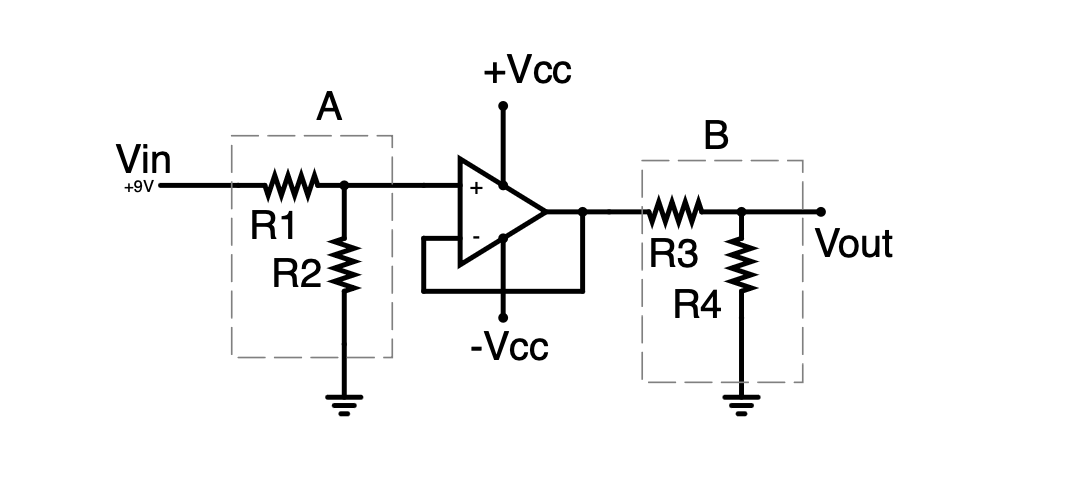

Figure: Schematic of two-dividers with an op-amp follower between them.

Note that the op-amp has two inputs (+, -), an output, and two power supply terminals (usually labeled +/- Vcc or +/- Vs).
The schematic is how to think about it from an electronics viewpoint.  On the other hand, we need to know how to connect it up in the lab on a breadboard. 


### Components on breadboard

Let's see how to correctly insert our op-amp (in our case a "741") **i**ntegrated **c**ircuit (IC) on your breadboard.  

**QUESTION:** In order to access all the pins, it must straddle the central channel. Why?

<span style="background-color:yellow">Bc you need to access each pin individually from each other. Each pin has a specific purpose that will be messed up if they're crossed.</span>

Be sure the pins on the bottom of the op amp are in a line and sticking out away from the body. If they are not, you can gently straighten them out, see Figure below.

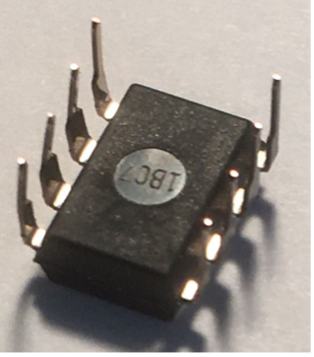

Figure: Op-amp upside down showing pins.

Now place the component across the central channel and gently press down as shown below.

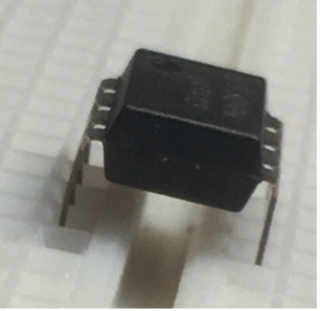, 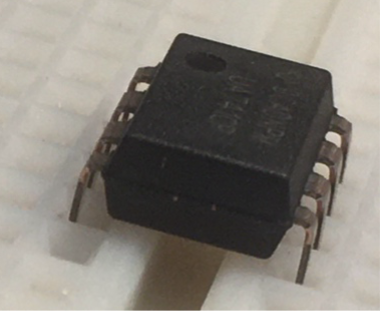

Figure: Op-amp straddling channel ready to insert (left); Op-amp straddling channel with pins pushed down.

The figure below shows the "pin out" of the 741 op-amp showing which physical terminals/pins are connected to which electrical input/outputs.

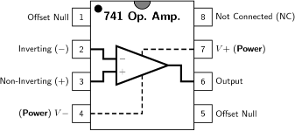

Figure: Pin out diagram for 741 op-amp. 

* To ensure proper use, look for the notch (at top) or dimple on the integrated circuit’s surface *when viewed from the top*. This feature should always be toward the left.  (Usually the printed label is correctly oriented as well.)
* Pins are numbered starting with 1 to the left of the dimple, and proceeding counterclockwise around the integrated circuit.
* You’ll always hook the power supply voltages up to +Vs (pin 7) and -Vs (pin 4) and your inputs to V- (pin 2) and V+ (pin 3). The output can be found on Vout (pin 6).  The input and output voltages are *relative to the ground point* in your circuit.  Pins 1, 8, and 5 are **N**ot **C**onnected (NC). **Ignore the dashed lines going to pins 4 and 7, those are not wires you will connect.**


### +/- Power supply

How can we get positive and negative (+/-) voltages for the +Vs/-Vs along with a ground?  We can use our power supply which has two voltage outputs.  Let's place the two outputs in series by connecting the negative terminal of output 1 to the positive terminal of output 2 and set both outputs to 15 V. (The 15 V is chosed as that is the limit for the 741 op amp.)  Then we can "declare" that the point between the two is the "ground" of our circuit and all voltages will be measured relative to that point.

The figure below shows the benchtop power supply.  Using *banana leads* make the connections shown.  Your $V_\text{in}$ will be a $9\;V$ battery (make sure the battery's ground is connected to the ground you made from your power supply).

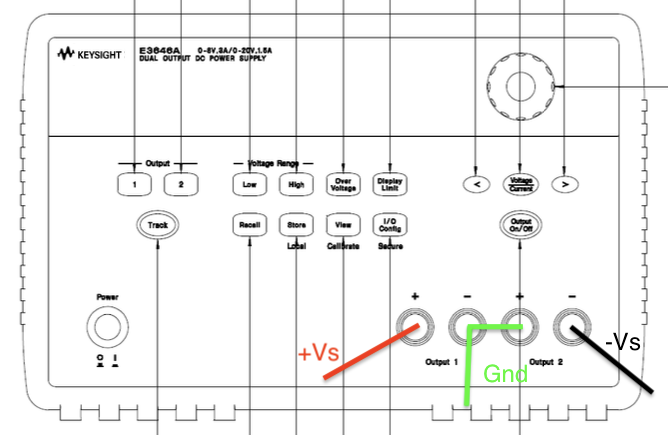

Figure: Benchtop power supply with connections for +Vs, -Vs, and GND.


## LABORATORY: Two-divider circuit with buffer

### Two-divider circuit with buffer

On your breadboard **build** the two-divider circuit (A then B) similar to the one you built before, but with an op-amp buffer between the A and B subcircuits. Keep the same resistors $R_1$...$R_4$.  

<span style="background-color:yellow">Include a breadboard diagram and a hookup diagram here.</span>
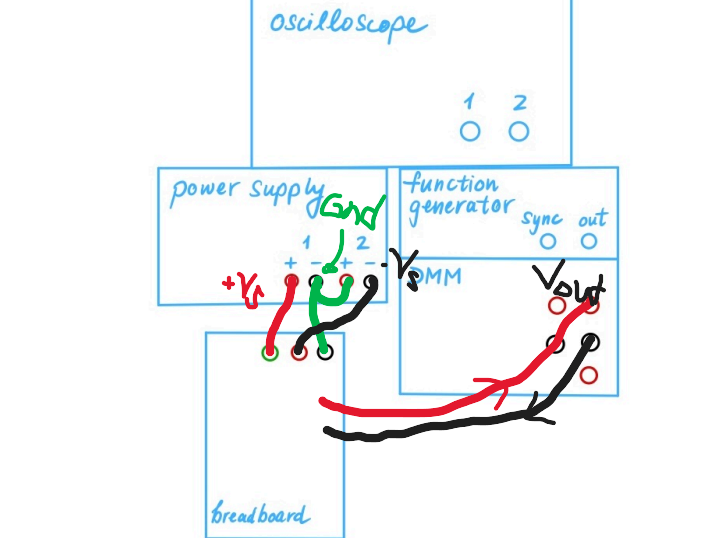

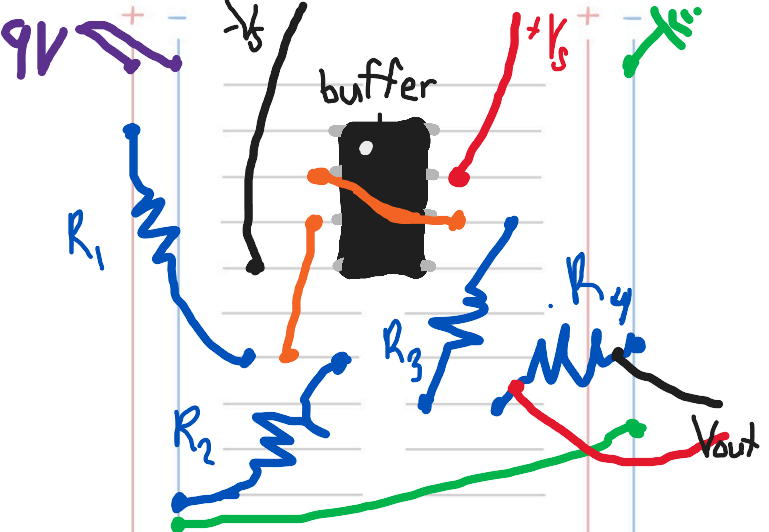

Measure the voltage at the output of divider A and the voltage at the input and output of divider B, $V_\text{out}$.  Calculate the gain for each voltage divider (while connected).

**QUESTION**: Are these gains what you expected?  Is the second circuit still loading the first circuit?  Does $G_\text{AB}=G_\text{A}G_\text{B}$?

<span style="background-color:yellow">

|Circuit (Divider)|Gain Calculated|Gain Measured|Percent Error|
|-|-|-|-|
|A|0.5|0.487|2.6%|
|B|0.662|0.677|2.27%|

<br>
Yes, they were only a couple of percent errors away from the gain's that I expected. The second circuit is not loading the first circuit. Yes, $G_\text{AB}$ does equal $G_\text{A}G_\text{B}$ </span>

### Two-divider circuit with buffer (reversed)

As before, reverse the order of the circuits in your two-divider circuit (B then A) with a buffer/follower between the B and A subcircuits. Keep the same resistors $R_1$...$R_4$. Measure the voltage at the output of divider B and the voltage at the input and output of divider A, $V_\text{out}$. 

**QUESTION**: Are these voltages what you expected?  Is the first circuit still loading the second circuit?  With the buffer between them, does the order of the circuits matter (A then B versus B then A)?

<span style="background-color:yellow">

|Circuit (Divider)|Gain Calculated|Gain Measured|Percent Error|
|-|-|-|-|
|A|0.5|0.397|20.6%|
|B|0.662|0.657|0.75%|

<br>
Mostly. Not much loading is happening any more, though for an unknown reason the voltage gain is wrong for divider A. The gain of divider B is totally fine, but not for divider A. It's much closer to what it should be compared to the reverse design without the buffer, but still with a significant percent error to the expected gain.<br>
In theory, the order of the dividers should not matter when using a buffer. 
</span>